
# Série Temporal - Previsão com ARIMA

## Objetivos
Neste notebook você aprenderá:

1. O que é previsão temporal
2. Como usar ARIMA
3. Como dividir treino e teste
4. Como fazer previsões
5. Como visualizar resultados


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

plt.rcParams['figure.figsize'] = (12,6)

# Criando dataset

In [3]:
datas = pd.date_range(start='2021-01-01', periods=36, freq='M')

vendas = [100,110,120,130,140,150,
          160,170,180,190,200,210,
          220,230,240,250,260,270,
          280,290,300,310,320,330,
          340,350,360,370,380,390,
          400,410,420,430,440,450]

base = pd.DataFrame({
    'data': datas,
    'vendas':vendas
})

base = base.set_index('data')

base.head()

C:\Users\Olive\AppData\Local\Temp\ipykernel_29072\2952175020.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datas = pd.date_range(start='2021-01-01', periods=36, freq='M')


,vendas
data,
2021-01-31,100
2021-02-28,110
2021-03-31,120
2021-04-30,130
2021-05-31,140



# Visualizando a série temporal


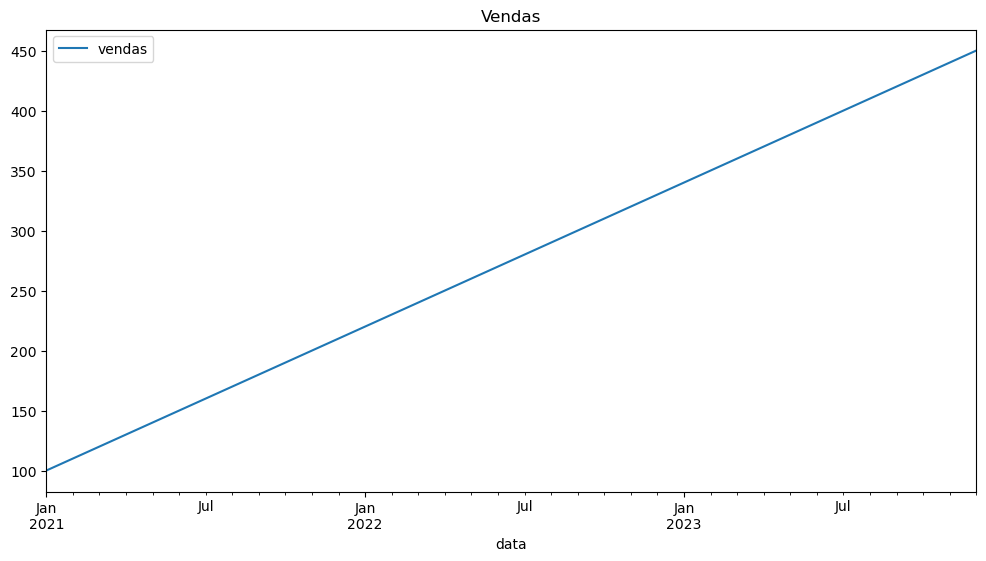

In [4]:
base.plot()
plt.title('Vendas')
plt.show()


# Separando treino e teste


In [5]:
treino = base.iloc[:30]
teste = base.iloc[30:]

print(treino.shape)
print(teste.shape)


(30, 1)
(6, 1)



# Criando modelo ARIMA


In [6]:
modelo = ARIMA(treino, order=(1,1,1))
modelo_treinado = modelo.fit()
print(modelo_treinado.summary())

c:\Users\Olive\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Olive\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Olive\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\Olive\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Olive\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization faile

                               SARIMAX Results                                
Dep. Variable:                 vendas   No. Observations:                   30
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 109.843
Date:                Sun, 24 May 2026   AIC                           -213.686
Time:                        20:01:12   BIC                           -209.584
Sample:                    01-31-2021   HQIC                          -212.401
                         - 06-30-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.0000   3.89e-06   2.57e+05      0.000       1.000       1.000
ma.L1          0.9999   9.56e-11   1.05e+10      0.000       1.000       1.000
sigma2      1.592e-05   6.01e-06      2.646      0.0


# Fazendo previsões


In [7]:
previsoes = modelo_treinado.forecast(steps=len(teste))
previsoes

2023-07-31    399.999949
2023-08-31    409.999797
2023-09-30    419.999544
2023-10-31    429.999189
2023-11-30    439.998733
2023-12-31    449.998175
Freq: ME, Name: predicted_mean, dtype: float64

# Comparando resultados

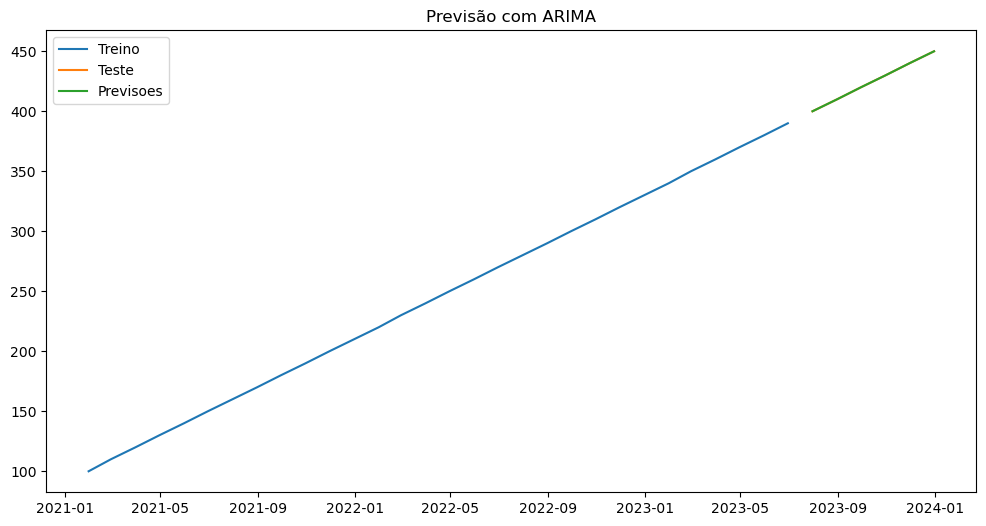

In [8]:
plt.plot(treino.index, treino['vendas'], label='Treino')
plt.plot(teste.index, teste['vendas'], label='Teste')
plt.plot(teste.index, previsoes, label='Previsoes')

plt.legend()
plt.title('Previsão com ARIMA')
plt.show()


# Explicando o ARIMA

ARIMA possui 3 parâmetros:

- p = autoregressão
- d = diferenciação
- q = média móvel

Exemplo:

ARIMA(1,1,1)
